##**PROJECT TOPIC :**
### ***A Hybrid NLP Framework for Detecting Depression and Anxiety on Social Platforms***



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **IMPORTS**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics.pairwise import cosine_similarity

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import networkx as nx

print('All imports successful.')

All imports successful.


###**DATASET**

In [ ]:
data = pd.read_csv(
    'https://raw.githubusercontent.com/Prinoor/nlp-anxiety-depression-detection/main/Filtered%20data.csv',
    encoding='latin-1', engine='python'
)
print(f'Shape: {data.shape}')
data.head()

Shape: (19294, 3)


,S.No.,Statement,Category
0,1,oh my gosh,Anxiety
1,2,"trouble sleeping, confused mind, restless hear...",Anxiety
2,3,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,4,I've shifted my focus to something else but I'...,Anxiety
4,5,"I'm restless and restless, it's been a month n...",Anxiety


### **PREPROCESSING**

In [ ]:
data.describe()

,S.No.,Statement,Category
count,19292,19283,19290
unique,19292,19225,2
top,19291,ni-ki best boy,Depression
freq,1,7,15403


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19294 entries, 0 to 19293
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   S.No.      19292 non-null  object
 1   Statement  19283 non-null  object
 2   Category   19290 non-null  object
dtypes: object(3)
memory usage: 452.3+ KB


In [ ]:
data.shape

(19294, 3)

In [ ]:
print('--- Basic Info ---')
print(data.info())
print(f'\nNull values:\n{data.isnull().sum()}')
print(f'\nDuplicates: {data.duplicated().sum()}')

# Drop nulls
data.dropna(inplace=True)

# Lowercase text
data['Statement'] = data['Statement'].str.lower()

print(f'\nCategory distribution:\n{data["Category"].value_counts()}')


--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19294 entries, 0 to 19293
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   S.No.      19292 non-null  object
 1   Statement  19283 non-null  object
 2   Category   19290 non-null  object
dtypes: object(3)
memory usage: 452.3+ KB
None

Null values:
S.No.         2
Statement    11
Category      4
dtype: int64

Duplicates: 1

Category distribution:
Category
Depression    15402
Anxiety        3880
Name: count, dtype: int64


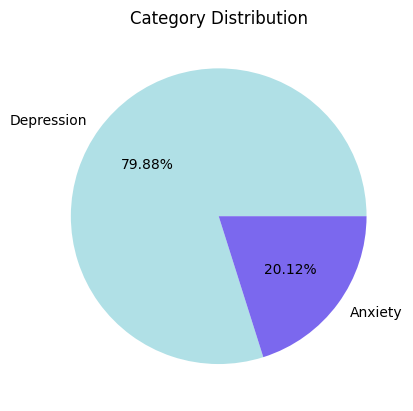

In [ ]:
# Pie chart - category distribution
data['Category'].value_counts().plot(
    kind='pie', autopct='%.2f%%',
    colors=['powderblue', 'mediumslateblue', 'salmon', 'palegreen', 'lemonchiffon']
)
plt.title('Category Distribution')
plt.ylabel('')
plt.show()

###**LABEL ENCODING AND TRAIN TEST SPLIT**

In [ ]:
label_enc = LabelEncoder()
data['label_encoded'] = label_enc.fit_transform(data['Category'])

X_train, X_test, y_train, y_test = train_test_split(
    data['Statement'],
    data['label_encoded'],
    test_size=0.2,
    random_state=42
)

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')
print(f'Classes: {list(label_enc.classes_)}')

Train size: 15425, Test size: 3857
Classes: ['Anxiety', 'Depression']


###**FEATURE ENGINEERING**

In [ ]:
# Main TF-IDF (5000 features) — used for all classical ML models
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')

TF-IDF matrix shape (train): (15425, 5000)


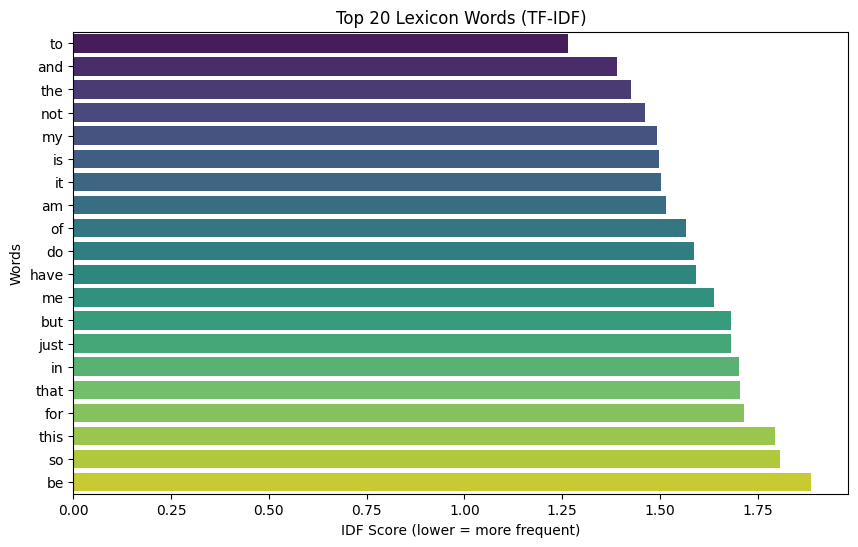

In [ ]:
# Top TF-IDF words bar chart
feature_names = np.array(tfidf.get_feature_names_out())
idf_scores = tfidf.idf_
sorted_idx = np.argsort(idf_scores)
top_n = 20
top_words = feature_names[sorted_idx[:top_n]]
top_scores = idf_scores[sorted_idx[:top_n]]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_scores, y=top_words, palette='viridis')
plt.xlabel('IDF Score (lower = more frequent)')
plt.ylabel('Words')
plt.title(f'Top {top_n} Lexicon Words (TF-IDF)')
plt.show()

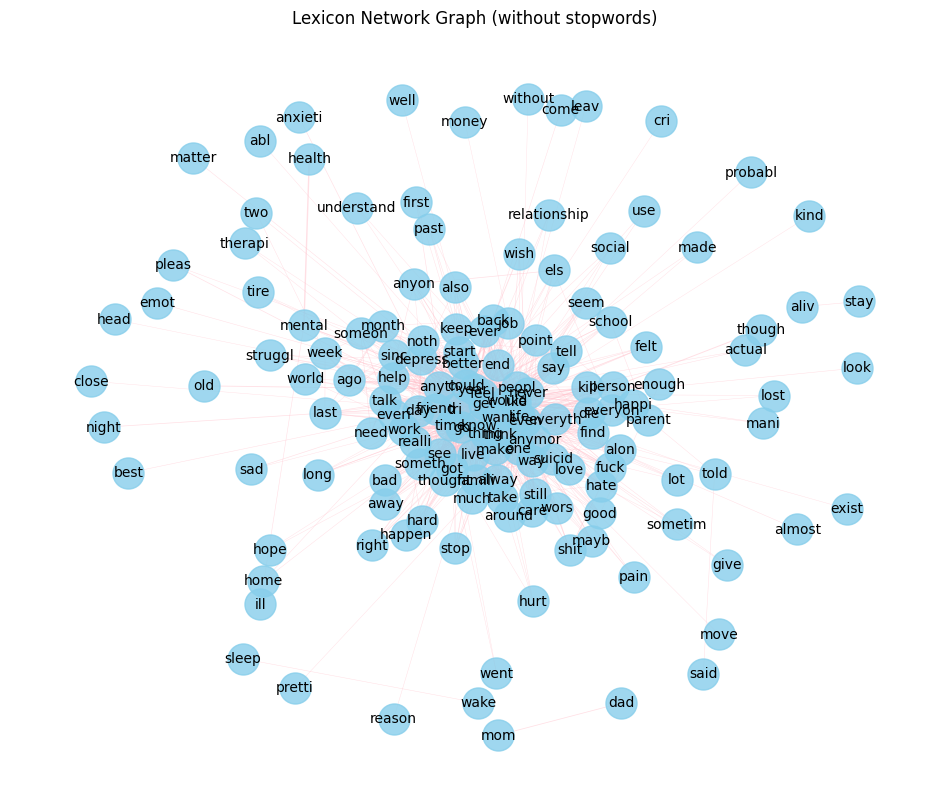

In [ ]:
# Lexicon Network Graph
# Uses a SEPARATE tfidf_graph (max_features=200) so it doesn't overwrite the main tfidf
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def stem_lemma_tokenizer(text):
    tokens = word_tokenize(text.lower())
    filtered = [t for t in tokens if t.isalpha() and t not in stop_words]
    return [stemmer.stem(lemmatizer.lemmatize(token)) for token in filtered]

tfidf_graph = TfidfVectorizer(max_features=200, tokenizer=stem_lemma_tokenizer)
X_train_graph = tfidf_graph.fit_transform(X_train)
words = tfidf_graph.get_feature_names_out()

word_sim_matrix = cosine_similarity(X_train_graph.T)

G = nx.Graph()
for i in range(len(words)):
    for j in range(i+1, len(words)):
        if word_sim_matrix[i, j] > 0.15:
            G.add_edge(words[i], words[j], weight=word_sim_matrix[i, j])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.3)
edges = G.edges(data=True)
weights = [edata['weight']*2 for _,_,edata in edges]
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='skyblue', alpha=0.8)
nx.draw_networkx_edges(G, pos, width=weights, edge_color='pink', alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif')
plt.title('Lexicon Network Graph (without stopwords)')
plt.axis('off')
plt.show()

### **MODEL TRAINING**

In [ ]:
results = []      # accumulates [name, acc, prec, rec, f1] for every model
model_scores = {} # accumulates name → accuracy for bar chart

print('Initialized results and model_scores.')


Initialized results and model_scores.


####**A. CLASSICAL ML MODELS**

In [ ]:
classical_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(),
    'SVM':                 SVC(),
    'KNN':                 KNeighborsClassifier()
}

for name, model in classical_models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec  = recall_score(y_test, preds, average='weighted')
    f1   = f1_score(y_test, preds, average='weighted')

    model_scores[name] = acc
    results.append([name, acc, prec, rec, f1])

    print(f'{name}')
    print(f'  Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}\n')

Logistic Regression
  Accuracy : 0.9637 | Precision: 0.9646 | Recall: 0.9637 | F1: 0.9640

Random Forest
  Accuracy : 0.9507 | Precision: 0.9512 | Recall: 0.9507 | F1: 0.9510

SVM
  Accuracy : 0.9679 | Precision: 0.9693 | Recall: 0.9679 | F1: 0.9683

KNN
  Accuracy : 0.2948 | Precision: 0.8338 | Recall: 0.2948 | F1: 0.2440



####**B. LSTM**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import numpy as np
import random
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

keras_tokenizer = KerasTokenizer(num_words=5000)
keras_tokenizer.fit_on_texts(X_train)
X_train_seq = pad_sequences(keras_tokenizer.texts_to_sequences(X_train), maxlen=100)
X_test_seq  = pad_sequences(keras_tokenizer.texts_to_sequences(X_test),  maxlen=100)

model_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=5000, output_dim=128),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(label_enc.classes_), activation='softmax')
])
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_lstm.fit(X_train_seq, y_train, epochs=3, batch_size=32, validation_split=0.1)

y_pred_lstm = tf.argmax(model_lstm.predict(X_test_seq), axis=1).numpy()

acc  = accuracy_score(y_test, y_pred_lstm)
prec = precision_score(y_test, y_pred_lstm, average='weighted')
rec  = recall_score(y_test, y_pred_lstm, average='weighted')
f1   = f1_score(y_test, y_pred_lstm, average='weighted')

model_scores['LSTM'] = acc
results.append(['LSTM', acc, prec, rec, f1])

print(f'LSTM  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')

Epoch 1/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.9227 - loss: 0.2221 - val_accuracy: 0.9760 - val_loss: 0.0807
Epoch 2/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 37s 63ms/step - accuracy: 0.9772 - loss: 0.0674 - val_accuracy: 0.9689 - val_loss: 0.0846
Epoch 3/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.9851 - loss: 0.0438 - val_accuracy: 0.9650 - val_loss: 0.1215
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
LSTM  Accuracy: 0.9679 | Precision: 0.9681 | Recall: 0.9679 | F1: 0.9679


####**C. DISTILBERT + LOGISTIC REGRESSION**

In [ ]:
import torch
print(torch.cuda.is_available())  # should print True on Colab T4

True


In [ ]:
import torch
from transformers import DistilBertTokenizer, DistilBertModel

tokenizer_bert = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = DistilBertModel.from_pretrained('distilbert-base-uncased')
bert_model.eval()
device = torch.device('cuda')
bert_model.to(device)

def get_bert_embeddings(texts, batch_size=32):
    all_embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer_bert(batch.tolist(), padding=True, truncation=True, max_length=64, return_tensors='pt')
            enc = {k: v.to(device) for k, v in enc.items()}  # ← moves to GPU
            out = bert_model(**enc)
            all_embeddings.append(out.last_hidden_state[:, 0, :].cpu().numpy())  # ← brings back to CPU
    return np.vstack(all_embeddings)

print('Generating embeddings (this takes a few minutes)...')
X_train_bert = get_bert_embeddings(X_train, batch_size=16)
X_test_bert  = get_bert_embeddings(X_test,  batch_size=16)

lr_bert = LogisticRegression(max_iter=200)
lr_bert.fit(X_train_bert, y_train)
y_pred_bert = lr_bert.predict(X_test_bert)

acc  = accuracy_score(y_test, y_pred_bert)
prec = precision_score(y_test, y_pred_bert, average='weighted')
rec  = recall_score(y_test, y_pred_bert, average='weighted')
f1   = f1_score(y_test, y_pred_bert, average='weighted')

model_scores['DistilBERT + LR'] = acc
results.append(['DistilBERT + LR', acc, prec, rec, f1])

print(f'DistilBERT + LR  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')

Generating embeddings (this takes a few minutes)...
DistilBERT + LR  Accuracy: 0.9668 | Precision: 0.9673 | Recall: 0.9668 | F1: 0.9670


####**D. STACKING ENSEMBLE**

In [ ]:
stacking_model = StackingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=500)),
        ('rf',  RandomForestClassifier(n_estimators=100, n_jobs=-1)),
        ('svc', LinearSVC())
    ],
    final_estimator=LogisticRegression(max_iter=500),
    n_jobs=-1
)
stacking_model.fit(X_train_tfidf, y_train)
stack_preds = stacking_model.predict(X_test_tfidf)

acc  = accuracy_score(y_test, stack_preds)
prec = precision_score(y_test, stack_preds, average='weighted')
rec  = recall_score(y_test, stack_preds, average='weighted')
f1   = f1_score(y_test, stack_preds, average='weighted')

model_scores['Stacking Ensemble'] = acc
results.append(['Stacking Ensemble', acc, prec, rec, f1])

print(f'Stacking Ensemble  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')

Stacking Ensemble  Accuracy: 0.9647 | Precision: 0.9653 | Recall: 0.9647 | F1: 0.9650


###**7. EXPLAINAIBILITY**

In [ ]:
!pip install lime -q
from lime.lime_text import LimeTextExplainer

# Uses its own tfidf_explainer and lr_explainer — does NOT touch the main tfidf
explainer = LimeTextExplainer(class_names=label_enc.classes_)

tfidf_explainer = TfidfVectorizer(max_features=5000)
tfidf_explainer.fit(X_train)

lr_explainer = LogisticRegression(max_iter=1000)
lr_explainer.fit(tfidf_explainer.transform(X_train), y_train)

i = 0  # index of test sample to explain
exp = explainer.explain_instance(
    X_test.iloc[i],
    classifier_fn=lambda x: lr_explainer.predict_proba(tfidf_explainer.transform(x))
)
exp.show_in_notebook()

###**8. RESULTS**

In [ ]:
df_results = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
print('\nOverall Model Comparison:')
print(df_results.to_string(index=False))


Overall Model Comparison:
              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.963702   0.964624 0.963702  0.964028
      Random Forest  0.950739   0.951225 0.950739  0.950952
                SVM  0.967851   0.969342 0.967851  0.968282
                KNN  0.294789   0.833816 0.294789  0.244037
               LSTM  0.967851   0.968065 0.967851  0.967944
    DistilBERT + LR  0.966814   0.967304 0.966814  0.967004
  Stacking Ensemble  0.964739   0.965305 0.964739  0.964958


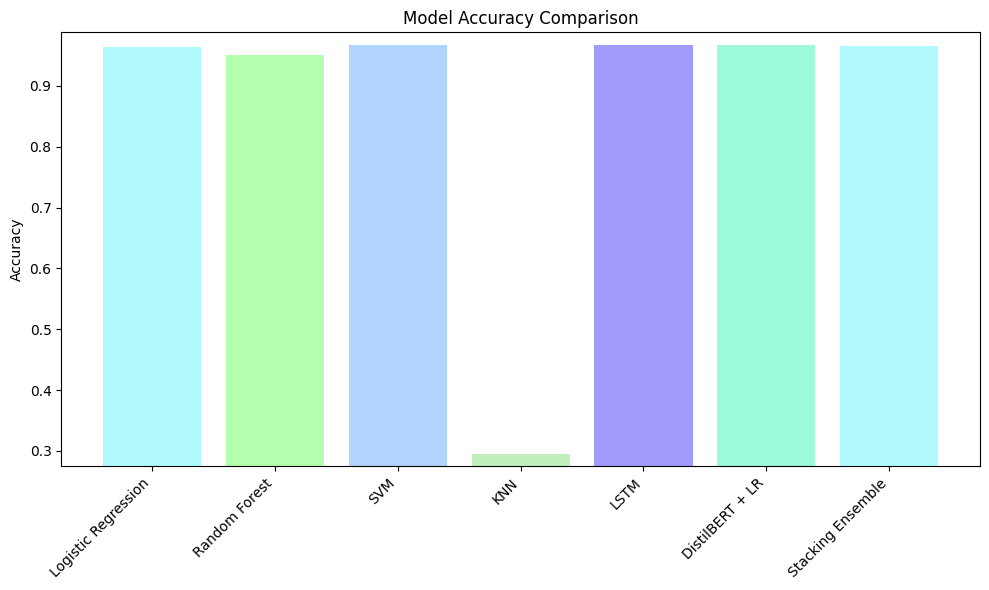

In [ ]:
# Accuracy bar chart
colors = ['#B0FAFD', '#B4FFAD', '#B0D4FD', '#C0F0BC', '#A09BFD', '#9DFBDC']
bar_colors = [colors[i % len(colors)] for i in range(len(model_scores))]

plt.figure(figsize=(10, 6))
plt.bar(model_scores.keys(), model_scores.values(), color=bar_colors)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45, ha='right')
min_acc = min(model_scores.values())
max_acc = max(model_scores.values())
plt.ylim(min_acc - 0.02, max_acc + 0.02)
plt.tight_layout()
plt.show()

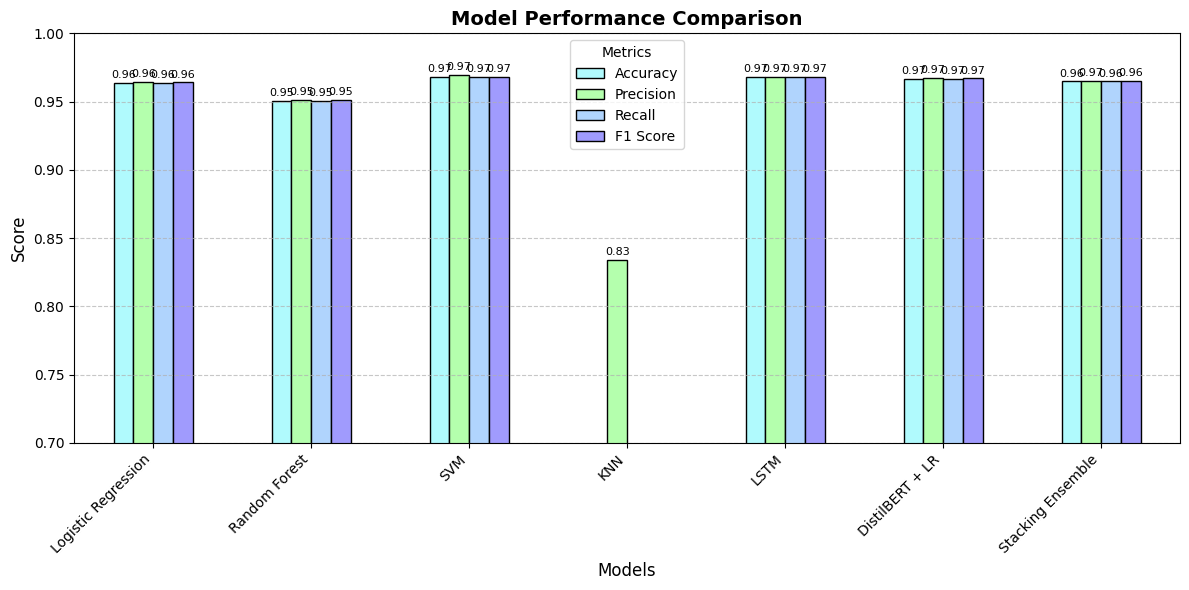

In [ ]:
# Grouped metrics bar chart
df_plot = df_results.set_index('Model')
ax = df_plot.plot(kind='bar', figsize=(12, 6),
                  color=['#B0FAFD', '#B4FFAD', '#B0D4FD', '#A09BFD'],
                  edgecolor='black')
plt.title('Model Performance Comparison', fontsize=14, weight='bold')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 1.0)
plt.legend(title='Metrics', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

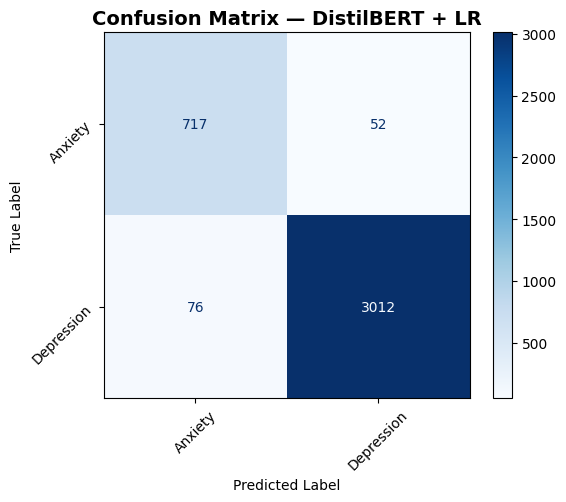

In [ ]:
# Confusion matrix (best model: DistilBERT + LR)
cm = confusion_matrix(y_test, y_pred_bert)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_enc.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title('Confusion Matrix — DistilBERT + LR', fontsize=14, weight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

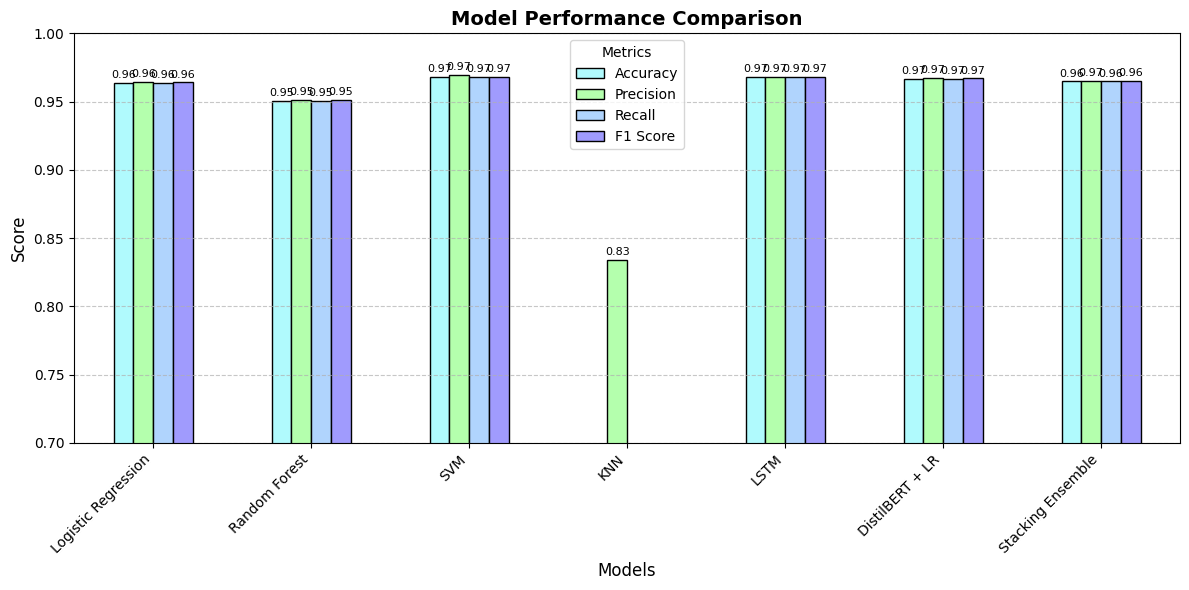

In [ ]:
# Grouped metrics bar chart
df_plot = df_results.set_index('Model')
ax = df_plot.plot(kind='bar', figsize=(12, 6),
                  color=['#B0FAFD', '#B4FFAD', '#B0D4FD', '#A09BFD'],
                  edgecolor='black')
plt.title('Model Performance Comparison', fontsize=14, weight='bold')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 1.0)
plt.legend(title='Metrics', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=8, padding=2)
plt.tight_layout()
plt.show()